# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
base = pd.read_csv('CARRO_CLIENTES.csv')

In [3]:
base.describe()

,User ID,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.106000,72689.000000,0.402000
std,288.819436,10.707073,34488.341867,0.490547
min,1.000000,18.000000,15000.000000,0.000000
25%,250.750000,32.000000,46375.000000,0.000000
50%,500.500000,40.000000,72000.000000,0.000000
75%,750.250000,48.000000,90000.000000,1.000000
max,1000.000000,63.000000,152500.000000,1.000000


In [4]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   str  
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(4), str(1)
memory usage: 39.2 KB


In [5]:
#drop na coluna ID
base = base.drop(columns=['User ID'])

# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [13]:
# fiz o encoded antes do treino/test

x = base.drop(columns=['Purchased'])
y = base['Purchased']

label_encoder = LabelEncoder()
base["Gender"] = label_encoder.fit_transform(base["Gender"])



# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

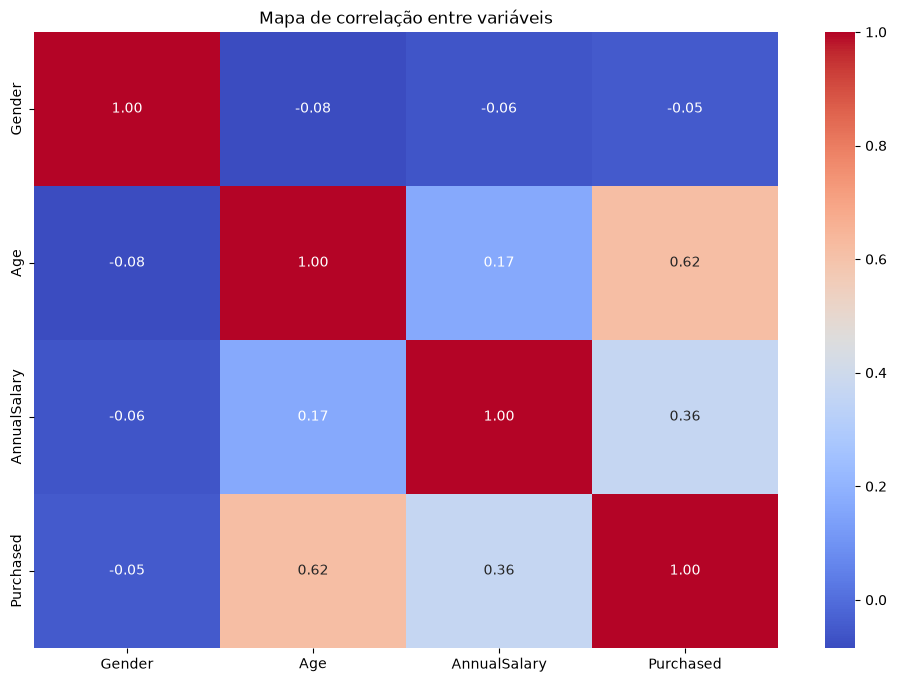

In [7]:
#matriz de correlaao
plt.figure(figsize=(12,8))
corr = base.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de correlação entre variáveis')
plt.show()

De acordo com a matriz de correção as variáveis que amis se correlacionam são: a idade e o salrario anual.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

3 hiperparâmetros úteis:

learning_rate: controla o quanto cada árvore influencia o modelo.

subsample: usa parte das linhas em cada árvore. Ajuda contra overfitting.

colsample_bytree: usa parte das colunas em cada árvore. Também ajuda contra overfitting.

In [16]:
xgbooster = xgb.XGBClassifier(
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
).fit(x_train, y_train)

# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [18]:
y_pred = xgbooster.predict(x_test)
y_pred_prob = xgbooster.predict_proba(x_test)

In [19]:
y_pred_prob

array([[7.9272449e-01, 2.0727552e-01],
       [1.4220715e-02, 9.8577929e-01],
       [9.9969399e-01, 3.0600201e-04],
       [7.6194924e-01, 2.3805076e-01],
       [2.5340039e-01, 7.4659961e-01],
       [7.4871838e-02, 9.2512816e-01],
       [1.0969102e-02, 9.8903090e-01],
       [9.9875420e-01, 1.2457994e-03],
       [9.9655217e-01, 3.4478335e-03],
       [9.8121190e-01, 1.8788122e-02],
       [9.5702630e-01, 4.2973686e-02],
       [9.9927831e-01, 7.2169071e-04],
       [9.1318494e-01, 8.6815044e-02],
       [9.9811363e-01, 1.8863812e-03],
       [6.8685770e-02, 9.3131423e-01],
       [1.7911786e-01, 8.2088214e-01],
       [4.9281603e-01, 5.0718397e-01],
       [1.4841133e-01, 8.5158867e-01],
       [8.4042907e-02, 9.1595709e-01],
       [9.9283797e-01, 7.1620629e-03],
       [9.8389971e-01, 1.6100306e-02],
       [1.8393695e-02, 9.8160630e-01],
       [4.0103793e-02, 9.5989621e-01],
       [9.9968356e-01, 3.1646737e-04],
       [3.9258480e-02, 9.6074152e-01],
       [9.3051887e-01, 6.

# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

In [20]:
# probabilidade de classe positiva, classe 1
y_pred_prob = xgbooster.predict_proba(x_test)[:, 1]

# transformando prababilidade em previsoes binarias
y_pred_binario = (y_pred_prob >= 0.5).astype(int)

In [21]:
# avaliaçao do modelo
print("Acurácia:", accuracy_score(y_test, y_pred_binario))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_binario))

print("Relatório de classificação:")
print(classification_report(y_test, y_pred_binario))

Acurácia: 0.91
Matriz de confusão:
[[106   6]
 [ 12  76]]
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       112
           1       0.93      0.86      0.89        88

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



O modelo retorna probabilidades para cada classe. Para transformar essas probabilidades em uma previsão binária, foi utilizado o limite de 0.5. Assim, probabilidades maiores ou iguais a 0.5 foram classificadas como 1, enquanto probabilidades menores que 0.5 foram classificadas como 0.

# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

In [23]:
importance = xgbooster.get_booster().get_score(importance_type='gain')
# convertendo um dicionario d eiportancias par ao dataframe

importance_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Importance'])
importance_df["Importance"] = importance_df["Importance"].astype(float)
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

        Feature  Importance
2  AnnualSalary    2.409239
1           Age    2.318217
0        Gender    0.576733


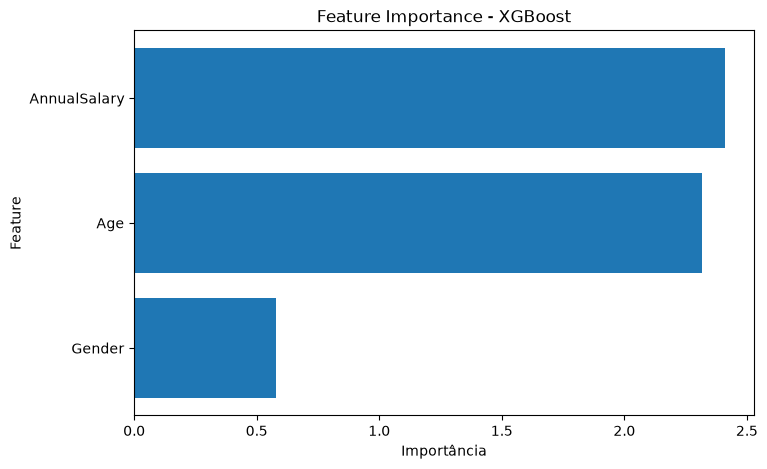

In [24]:
importance_df_plot = importance_df.sort_values("Importance", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance_df_plot["Feature"], importance_df_plot["Importance"])
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

A feature importance foi calculada usando o tipo gain, que mede o quanto cada variável contribuiu para melhorar as divisões das árvores do modelo. As variáveis mais importantes no XGBoost podem não ser exatamente as mesmas com maior correlação, pois a correlação mede apenas relação linear, enquanto o XGBoost captura relações não lineares e interações entre variáveis.